In [1]:
from itertools import combinations
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from crucio import SMOTEENN

from IPython.display import display

RANDOM_STATE = 42
TARGET_COL = "Outcome"

# Serology results, blood counts, temperature and fever duration separate the two Outcome
# classes almost perfectly (see 00_model), so they are dropped here as well.
LEAKAGE_COLS = [
    "NS1",
    "IgG",
    "IgM",
    "Platelet_Count",
    "WBC_Count",
    "Body_Temperature",
    "Fever_Duration",
]
DROP_COLS = LEAKAGE_COLS + ["District"]

CATEGORICAL_COLS = ["Gender", "AreaType", "HouseType", "Joint_Pain"]

# best outlier setup picked in 04_Outlier_Method
OUTLIER_PARAMS = {"n_neighbors": 20, "leaf_size": 30, "contamination": 0.05}

# the 6 features RFECV kept in every outer fold (05_Feature_Select)
SELECTED_FEATURES = [
    "Headache",
    "Retro_Orbital_Pain",
    "Myalgia",
    "Rash",
    "Joint_Pain_None",
    "Joint_Pain_Severe",
]

# best variant in 08_Model_Selection
N_COMPONENTS = 5

poverty = pd.read_csv("area_poverty_table.csv")
AREA_TO_HCR = poverty.set_index("Area")["HCR_upper_2022"]

In [2]:
class ColumnPreparer(BaseEstimator, TransformerMixin):
    """Step 1 — missing values (02): drop the leaking columns, fill the NaNs, one-hot encode."""

    def __init__(self, drop_cols=DROP_COLS, categorical_cols=CATEGORICAL_COLS):
        self.drop_cols = drop_cols
        self.categorical_cols = categorical_cols

    def _base_frame(self, X: pd.DataFrame) -> pd.DataFrame:
        out = X.copy()
        out = out.rename(columns=lambda col: col.strip())
        out = out.drop(columns=[c for c in list(self.drop_cols) + [TARGET_COL] if c in out.columns])
        # poverty rate of the thana the patient lives in (see 03_Feature_Engineering)
        out["Area_HCR"] = out["Area"].map(AREA_TO_HCR)
        return out

    def _fill(self, frame: pd.DataFrame) -> pd.DataFrame:
        out = frame.copy()
        # A missing Joint_Pain means the symptom was not reported (see 02_Missing_Values)
        out["Joint_Pain"] = out["Joint_Pain"].fillna("None")
        for col, value in self.numeric_medians_.items():
            if col in out.columns:
                out[col] = out[col].fillna(value)
        for col, value in self.category_modes_.items():
            if col in out.columns:
                out[col] = out[col].fillna(value)
        return out

    def fit(self, X: pd.DataFrame, y=None):
        frame = self._base_frame(X)
        frame["Joint_Pain"] = frame["Joint_Pain"].fillna("None")
        self.numeric_medians_ = frame.select_dtypes(include="number").median().to_dict()
        self.category_modes_ = {col: frame[col].mode()[0] for col in self.categorical_cols}
        encoded = pd.get_dummies(
            self._fill(frame), columns=self.categorical_cols, drop_first=True, dtype=int
        )
        self.feature_names_ = encoded.columns.tolist()
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        encoded = pd.get_dummies(
            self._fill(self._base_frame(X)),
            columns=self.categorical_cols,
            drop_first=True,
            dtype=int,
        )
        # a test batch may miss a category entirely, so replay the training column list
        return encoded.reindex(columns=self.feature_names_, fill_value=0)

In [3]:
class BinningEngineer(BaseEstimator, TransformerMixin):
    """Step 2 — feature engineering (03): Area → poverty bin code, Age → one-hot balanced bins."""

    def __init__(self, n_area_bins=5, n_age_bins=5, balance_tolerance=0.10):
        self.n_area_bins = n_area_bins
        self.n_age_bins = n_age_bins
        self.balance_tolerance = balance_tolerance

    @staticmethod
    def _find_balanced_cuts(sizes, n_bins):
        """Split an ordered list of group sizes into `n_bins` contiguous blocks of near-equal total size."""
        sizes = np.asarray(sizes, dtype=float)
        cumulative = np.concatenate([[0], sizes.cumsum()])
        target = sizes.sum() / n_bins
        best_score, best_bounds = None, None
        for cuts in combinations(range(1, len(sizes)), n_bins - 1):
            bounds = (0,) + cuts + (len(sizes),)
            counts = np.diff(cumulative[list(bounds)])
            deviations = np.abs(counts - target)
            score = (deviations.max(), (deviations ** 2).sum())
            if best_score is None or score < best_score:
                best_score, best_bounds = score, bounds
        return list(best_bounds)

    @staticmethod
    def _enumerate_splits(n_groups, n_bins):
        return np.array(
            [(0,) + cuts + (n_groups,) for cuts in combinations(range(1, n_groups), n_bins - 1)],
            dtype=np.int32,
        )

    @staticmethod
    def _score_splits(splits, group_sizes, group_positives):
        group_sizes = np.asarray(group_sizes, dtype=float)
        group_positives = np.asarray(group_positives, dtype=float)
        cum_n = np.concatenate([[0], group_sizes.cumsum()])
        cum_p = np.concatenate([[0], group_positives.cumsum()])
        n = np.diff(cum_n[splits], axis=1)
        p = np.diff(cum_p[splits], axis=1)
        total_n, total_p = group_sizes.sum(), group_positives.sum()
        target = total_n / (splits.shape[1] - 1)
        expected_pos = n * total_p / total_n
        expected_neg = n * (total_n - total_p) / total_n
        with np.errstate(divide="ignore", invalid="ignore"):
            chi2 = np.nan_to_num(
                (p - expected_pos) ** 2 / expected_pos + ((n - p) - expected_neg) ** 2 / expected_neg
            ).sum(axis=1)
        return {"balance_deviation": np.abs(n - target).max(axis=1), "chi2": chi2}

    def _fit_area_edges(self, X: pd.DataFrame) -> None:
        areas = (
            X[["Area"]].dropna()
            .groupby("Area", as_index=False).size().rename(columns={"size": "n_patients"})
            .merge(poverty[["Area", "HCR_upper_2022"]], on="Area", how="left")
            .sort_values(["HCR_upper_2022", "Area"], kind="mergesort")
            .reset_index(drop=True)
        )
        bounds = self._find_balanced_cuts(areas["n_patients"].values, self.n_area_bins)
        # midpoint between the last area of a bin and the first area of the next one
        inner_edges = [
            round((areas.loc[b - 1, "HCR_upper_2022"] + areas.loc[b, "HCR_upper_2022"]) / 2, 3)
            for b in bounds[1:-1]
        ]
        self.area_edges_ = [-np.inf] + inner_edges + [np.inf]
        self.area_labels_ = [f"Q{i}" for i in range(1, self.n_area_bins + 1)]

    def _fit_age_edges(self, X: pd.DataFrame, y: pd.Series) -> None:
        frame = pd.DataFrame({"Age": X["Age"].to_numpy(), TARGET_COL: np.asarray(y, dtype=float)})
        counts = (
            frame.groupby("Age")
            .agg(n_patients=(TARGET_COL, "size"), positives=(TARGET_COL, "sum"))
            .sort_index()
        )
        age_values = counts.index.to_numpy()
        splits = self._enumerate_splits(len(age_values), self.n_age_bins)
        scores = self._score_splits(splits, counts["n_patients"].to_numpy(), counts["positives"].to_numpy())

        tol = self.balance_tolerance * len(frame) / self.n_age_bins
        allowed = np.where(scores["balance_deviation"] <= tol)[0]
        if len(allowed) == 0:
            raise ValueError("No age split satisfies the balance tolerance.")
        bounds = splits[allowed[scores["chi2"][allowed].argmax()]]

        self.age_edges_ = (
            [-np.inf]
            + [(age_values[b - 1] + age_values[b]) / 2 for b in bounds[1:-1]]
            + [np.inf]
        )
        self.age_labels_ = [
            f"{age_values[bounds[i]]}-{age_values[bounds[i + 1] - 1]}" for i in range(self.n_age_bins)
        ]

    def fit(self, X: pd.DataFrame, y=None):
        if y is None:
            raise ValueError("BinningEngineer needs the target to pick the Age cut points.")
        self._fit_area_edges(X)
        self._fit_age_edges(X, y)
        self.feature_names_ = self.transform(X).columns.tolist()
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        out = X.copy()
        out["Area_HCR"] = out["Area"].map(AREA_TO_HCR)

        area_bin = pd.cut(out["Area_HCR"], bins=self.area_edges_, labels=self.area_labels_, ordered=True)
        out["Area_bin_code"] = area_bin.cat.codes                      # ordinal: Q1 < ... < Q5

        age_bin = pd.cut(out["Age"], bins=self.age_edges_, labels=self.age_labels_, ordered=True)
        for label in self.age_labels_[1:]:                             # drop_first, labels fixed at fit
            out[f"Age_bin_{label}"] = (age_bin == label).astype(int)

        return out.drop(columns=["Area", "Age", "Area_HCR"])

In [4]:
class FeatureSelector(BaseEstimator, TransformerMixin):
    """Step 3 — feature selection (05): keep the 6 columns RFECV agreed on in every outer fold."""

    def __init__(self, features=SELECTED_FEATURES):
        self.features = features

    def fit(self, X: pd.DataFrame, y=None):
        self.feature_names_ = list(self.features)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return X.reindex(columns=self.feature_names_, fill_value=0)

In [5]:
class OutlierFilter(BaseEstimator):
    """Step 4 — outlier filtering (04): LocalOutlierFactor, training rows only."""

    def __init__(self, n_neighbors=20, leaf_size=30, contamination=0.05):
        self.n_neighbors = n_neighbors
        self.leaf_size = leaf_size
        self.contamination = contamination

    def fit_resample(self, X: pd.DataFrame, y: pd.Series) -> Tuple[pd.DataFrame, pd.Series]:
        detector = LocalOutlierFactor(
            n_neighbors=self.n_neighbors,
            leaf_size=self.leaf_size,
            contamination=self.contamination,
        )
        labels = detector.fit_predict(X)
        mask = pd.Series(labels == 1, index=X.index)
        self.n_removed_ = int((~mask).sum())
        return X.loc[mask].copy(), y.loc[mask].copy()


class CrucioBalancer(BaseEstimator):
    """Step 5 — class balancing (06): Crucio SMOTEENN, training rows only."""

    def __init__(self, balancer_cls=SMOTEENN, target_col=TARGET_COL):
        self.balancer_cls = balancer_cls
        self.target_col = target_col

    def fit_resample(self, X: pd.DataFrame, y: pd.Series) -> Tuple[pd.DataFrame, pd.Series]:
        # the Crucio API balances a frame that carries the target column
        proc_df = X.reset_index(drop=True).copy()
        proc_df[self.target_col] = pd.Series(np.asarray(y)).astype(int)

        balanced_df = self.balancer_cls().balance(proc_df, self.target_col)
        X_balanced = balanced_df.drop(columns=[self.target_col]).reset_index(drop=True)
        y_balanced = balanced_df[self.target_col].astype(int).reset_index(drop=True)

        self.n_added_ = len(X_balanced) - len(X)
        return X_balanced, y_balanced

In [ ]:
class ResamplingPipeline(BaseEstimator):
    """A Pipeline that also accepts steps changing the number of rows.

    A step exposing `fit_resample` runs during `fit` only; on the prediction path it is skipped —
    exactly the behaviour we want from outlier filtering and class balancing.
    """

    _estimator_type = "classifier"

    def __init__(self, steps: List[Tuple[str, object]]):
        self.steps = steps

    def fit(self, X: pd.DataFrame, y):
        self.steps_ = [(name, clone(est)) for name, est in self.steps]
        Xt = X
        yt = pd.Series(np.asarray(y), index=getattr(X, "index", None))

        self.fit_trace_ = [{"step": "input", "rows": len(Xt), "columns": Xt.shape[1]}]
        for name, estimator in self.steps_[:-1]:
            if hasattr(estimator, "fit_resample"):
                Xt, yt = estimator.fit_resample(Xt, yt)          # training-time only
            else:
                Xt = estimator.fit_transform(Xt, yt)
            self.fit_trace_.append({"step": name, "rows": Xt.shape[0], "columns": Xt.shape[1]})

        self.steps_[-1][1].fit(Xt, yt)
        self.named_steps_ = dict(self.steps_)
        self.classes_ = getattr(self.steps_[-1][1], "classes_", None)
        return self

    def transform(self, X: pd.DataFrame):
        Xt = X
        for _, estimator in self.steps_[:-1]:
            if not hasattr(estimator, "fit_resample"):
                Xt = estimator.transform(Xt)
        return Xt

    def predict(self, X: pd.DataFrame):
        return self.steps_[-1][1].predict(self.transform(X))

    def predict_proba(self, X: pd.DataFrame):
        return self.steps_[-1][1].predict_proba(self.transform(X))


def build_final_pipeline() -> ResamplingPipeline:
    return ResamplingPipeline([
        ("prepare",  ColumnPreparer()),                                       # 02_Missing_Values
        ("engineer", BinningEngineer()),                                      # 03_Feature_Engineering
        ("select",   FeatureSelector()),                                      # 05_Feature_Select
        ("outliers", OutlierFilter(**OUTLIER_PARAMS)),                        # 04_Outlier_Method
        ("balance",  CrucioBalancer()),                                       # 06_Class_Balancing
        ("scaler",   StandardScaler()),                                       # 07_PCA
        ("pca",      PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)),
        ("model",    GaussianNB()),                                           # 08_Model_Selection
    ])


build_final_pipeline()

,steps,"[('prepare', ...), ('engineer', ...), ...]"


In [7]:
def split_train_val_test(
    df: pd.DataFrame,
    random_state: int = RANDOM_STATE,
    ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """80 / 10 / 10 split with a fixed seed, so every notebook can rebuild the same subsets.

    The test subset is returned untouched and must not take part in any selection step.
    """
    df_dev, df_test = train_test_split(df, test_size=0.1, random_state=random_state)
    df_train, df_val = train_test_split(df_dev, test_size=1 / 9, random_state=random_state)
    return df_train, df_val, df_test


df = pd.read_csv("data.csv").rename(columns=lambda col: col.strip())
df_train_raw, df_val_raw, df_test_raw = split_train_val_test(df, RANDOM_STATE)

# model selection is over: train + validation become the development set the final model is fitted on
df_dev_raw = pd.concat([df_train_raw, df_val_raw], axis=0)

X_dev, y_dev = df_dev_raw.drop(columns=[TARGET_COL]), df_dev_raw[TARGET_COL]
X_test, y_test = df_test_raw.drop(columns=[TARGET_COL]), df_test_raw[TARGET_COL]

print(f"development: {len(X_dev)} rows | test (held out): {len(X_test)} rows")
print(f"positives   development: {y_dev.mean():.3f} | test: {y_test.mean():.3f}")

# the pipeline is fed the raw columns, exactly as they come out of the CSV
display(X_test.head())

development: 900 rows | test (held out): 100 rows
positives   development: 0.529 | test: 0.570


,Gender,Age,NS1,IgG,IgM,Area,AreaType,HouseType,District,Fever_Duration,Body_Temperature,Platelet_Count,WBC_Count,Joint_Pain,Headache,Retro_Orbital_Pain,Myalgia,Rash
521,Male,23,1,1,0,Kamrangirchar,Developed,Tinshed,Dhaka,3,39.1,70622.0,2542.0,Moderate,1,0,1,1.0
737,Male,56,1,1,0,Kalabagan,Developed,Building,Dhaka,6,39.3,72034.0,2681.0,Moderate,1,0,1,1.0
740,Female,32,0,0,1,Shahbagh,Undeveloped,Tinshed,Dhaka,0,36.9,181711.0,6370.0,NaN,0,0,1,0.0
660,Male,18,0,0,0,New Market,Undeveloped,Building,Dhaka,1,37.4,196336.0,6957.0,NaN,0,0,0,0.0
411,Male,24,0,0,1,Hazaribagh,Developed,Other,Dhaka,0,36.4,181164.0,6660.0,Severe,0,0,0,0.0


In [8]:
final_pipeline = build_final_pipeline()
final_pipeline.fit(X_dev, y_dev)

trace = pd.DataFrame(final_pipeline.fit_trace_)
trace["rows_delta"] = trace["rows"].diff().fillna(0).astype(int)
display(trace)

engineer = final_pipeline.named_steps_["engineer"]
print("Area bin edges (HCR):", engineer.area_edges_[1:-1])
print("Age bin edges        :", engineer.age_edges_[1:-1])
print("Age bin labels       :", engineer.age_labels_)
print()
print(f"rows dropped by LocalOutlierFactor: {final_pipeline.named_steps_['outliers'].n_removed_}")
print(f"rows added by SMOTEENN            : {final_pipeline.named_steps_['balance'].n_added_}")
print()
print("explained variance of the 5 kept components:",
      np.round(final_pipeline.named_steps_["pca"].explained_variance_ratio_.cumsum(), 4))

,step,rows,columns,rows_delta
0,input,900,18,0
1,prepare,900,13,0
2,engineer,900,15,0
3,select,900,6,0
4,outliers,855,6,-45
5,balance,894,6,39
6,scaler,894,6,0
7,pca,894,5,0


Area bin edges (HCR): [np.float64(2.75), np.float64(4.5), np.float64(6.55), np.float64(8.6)]
Age bin edges        : [np.float64(18.5), np.float64(30.5), np.float64(41.5), np.float64(51.5)]
Age bin labels       : ['8-18', '19-30', '31-41', '42-51', '52-65']

rows dropped by LocalOutlierFactor: 45
rows added by SMOTEENN            : 39

explained variance of the 5 kept components: [0.5341 0.6677 0.777  0.877  0.9571]


In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_dev, y_dev), start=1):
    fold_pipeline = build_final_pipeline()
    fold_pipeline.fit(X_dev.iloc[train_idx], y_dev.iloc[train_idx])

    y_true_fold = y_dev.iloc[val_idx]
    y_pred_fold = fold_pipeline.predict(X_dev.iloc[val_idx])

    cv_rows.append({
        "fold": fold,
        "recall": recall_score(y_true_fold, y_pred_fold),
        "precision": precision_score(y_true_fold, y_pred_fold),
        "f1": f1_score(y_true_fold, y_pred_fold),
        "accuracy": accuracy_score(y_true_fold, y_pred_fold),
    })

cv_results = pd.DataFrame(cv_rows).set_index("fold")
pd.set_option("display.float_format", "{:.4f}".format)
display(cv_results)

print("5-fold CV on the development rows:")
for metric in ["recall", "precision", "f1", "accuracy"]:
    print(f"  {metric:<10}: {cv_results[metric].mean():.4f} +/- {cv_results[metric].std(ddof=0):.4f}")

,recall,precision,f1,accuracy
fold,,,,
1,0.9688,0.8857,0.9254,0.9167
2,0.9895,0.8952,0.9400,0.9333
3,0.9895,0.9038,0.9447,0.9389
4,0.9895,0.9126,0.9495,0.9444
5,0.9474,0.9091,0.9278,0.9222


5-fold CV on the development rows:
  recall    : 0.9769 +/- 0.0168
  precision : 0.9013 +/- 0.0097
  f1        : 0.9375 +/- 0.0094
  accuracy  : 0.9311 +/- 0.0103


In [10]:
y_pred = final_pipeline.predict(X_test)
y_proba = final_pipeline.predict_proba(X_test)[:, 1]

print("Classification report — held-out test set (n = {})\n".format(len(y_test)))
print(classification_report(y_test, y_pred, target_names=["No Dengue (0)", "Dengue (1)"], digits=4))

Classification report — held-out test set (n = 100)

               precision    recall  f1-score   support

No Dengue (0)     1.0000    0.8372    0.9114        43
   Dengue (1)     0.8906    1.0000    0.9421        57

     accuracy                         0.9300       100
    macro avg     0.9453    0.9186    0.9268       100
 weighted avg     0.9377    0.9300    0.9289       100



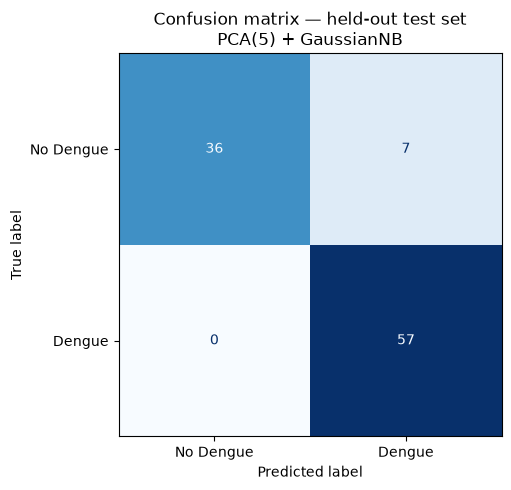

true negatives :  36   false positives:   7
false negatives:   0   true positives :  57


In [11]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["No Dengue", "Dengue"]).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion matrix — held-out test set\nPCA(5) + GaussianNB")
plt.tight_layout()
plt.show()

print(f"true negatives : {tn:>3}   false positives: {fp:>3}")
print(f"false negatives: {fn:>3}   true positives : {tp:>3}")

In [12]:
test_metrics = pd.DataFrame([{
    "recall": recall_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "accuracy": accuracy_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}], index=["test"])

comparison = pd.concat([
    cv_results[["recall", "precision", "f1", "accuracy"]].mean().to_frame("dev CV (5-fold)").T,
    test_metrics,
])
display(comparison)

,recall,precision,f1,accuracy,roc_auc
dev CV (5-fold),0.9769,0.9013,0.9375,0.9311,NaN
test,1.0000,0.8906,0.9421,0.9300,0.9853


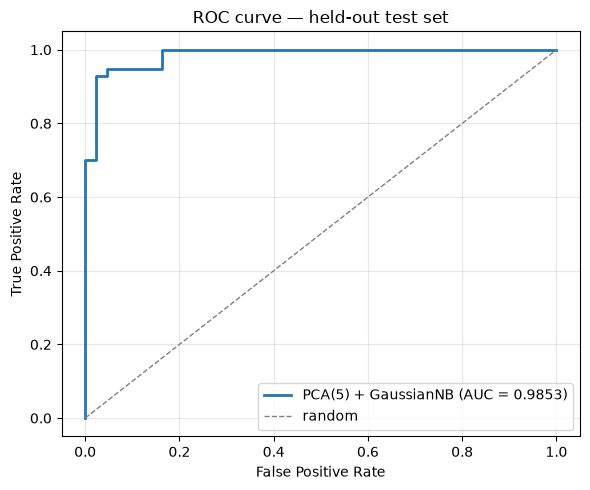

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, label=f"PCA(5) + GaussianNB (AUC = {roc_auc_score(y_test, y_proba):.4f})")
ax.plot([0, 1], [0, 1], ls="--", lw=1, color="gray", label="random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curve — held-out test set")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Conclusion

The final pipeline — median/mode imputation with `Joint_Pain = None`, poverty and age binning, the six
selected symptom columns, LOF outlier filtering, SMOTEENN balancing, `StandardScaler` + `PCA(5)` and a
`GaussianNB` classifier — reaches **recall 1.00** on the 100 held-out patients: every dengue-positive
patient in the test set is flagged. It pays for that with 7 false positives out of 43 negatives, giving
precision 0.89, F1 0.94, accuracy 0.93 and ROC AUC 0.985.

Two things are worth saying plainly about that number:

* the test score is in line with the development CV (recall 0.977, F1 0.938), so the pipeline is not
  over-fitted to the rows it was tuned on — if anything the test split is slightly kind to it;
* the recall rests on 57 positive test rows, and 57/57 has a 95 % Wilson interval of 0.94–1.00. The honest
  reading is "the model misses very few positives", not "the model never misses one".

The error pattern is exactly the one the metric choice was aiming for. Every mistake is a false positive:
a patient sent for a confirmatory serology test who turns out to be negative. In a screening setting that is
the cheap error, and the model makes no expensive ones.

Worth remembering what the model is *not* seeing: `NS1`, `IgG`, `IgM`, the blood counts, the body
temperature and the fever duration were dropped as leaking columns back in `00_model` — they identify the
outcome almost deterministically because they *are* the diagnosis. What is left is a symptom-and-demographics
questionnaire, and the interesting result is that four self-reported symptoms plus joint pain severity carry
almost all of the signal: `Headache`, `Retro_Orbital_Pain`, `Myalgia`, `Rash`, `Joint_Pain_None` and
`Joint_Pain_Severe`. Age, gender, house type and even the area poverty rate were dropped by RFECV in all
five outer folds. That is a genuinely useful finding for a public-health screening tool: a six-question form
is enough to decide who needs a lab test.